# FGSM & PGD 白盒对抗攻击实验

本 notebook 在 CIFAR-10 数据集上训练一个简单的 CNN（SimpleCNN），然后使用 **FGSM**（Fast Gradient Sign Method）和 **PGD**（Projected Gradient Descent）两种白盒攻击方法生成对抗样本，并分析攻击强度与模型准确率的关系。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SimpleCNN 网络结构：保持 conv1 3->16, conv2 16->32, fc1 2048->128, fc2 128->10
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def train_model(model, train_loader, epochs=15, lr=1e-3):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        acc = 100.0 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {acc:.2f}%")
    return model

# CIFAR-10 数据已放在 ./data/cifar-10-batches-py/
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

model = SimpleCNN().to(device)
model = train_model(model, train_loader, epochs=15, lr=1e-3)
model.eval()
print("Training complete.")


Epoch 1/15, Loss: 1.5641, Train Acc: 43.97%
Epoch 2/15, Loss: 1.2458, Train Acc: 55.92%
Epoch 3/15, Loss: 1.1149, Train Acc: 60.72%
Epoch 4/15, Loss: 1.0196, Train Acc: 64.06%
Epoch 5/15, Loss: 0.9586, Train Acc: 66.35%
Epoch 6/15, Loss: 0.8939, Train Acc: 68.51%
Epoch 7/15, Loss: 0.8463, Train Acc: 70.49%
Epoch 8/15, Loss: 0.8015, Train Acc: 72.09%
Epoch 9/15, Loss: 0.7664, Train Acc: 73.06%
Epoch 10/15, Loss: 0.7242, Train Acc: 74.56%
Epoch 11/15, Loss: 0.6900, Train Acc: 75.82%
Epoch 12/15, Loss: 0.6553, Train Acc: 77.08%
Epoch 13/15, Loss: 0.6212, Train Acc: 78.12%
Epoch 14/15, Loss: 0.5971, Train Acc: 79.12%
Epoch 15/15, Loss: 0.5646, Train Acc: 80.25%
Training complete.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def show_images(original, adversarial):
    """可视化原始样本和对抗样本"""
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    orig_np = original.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    adv_np = adversarial.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    axs[0].imshow(np.clip(orig_np, 0, 1))
    axs[0].set_title("Original Image")
    axs[1].imshow(np.clip(adv_np, 0, 1))
    axs[1].set_title("Adversarial Image")
    plt.show()

def get_correct_sample(model, test_loader):
    """从测试集中挑选一个模型预测正确的真实样本"""
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images).argmax(dim=1)
            if pred.item() == labels.item():
                return images, labels
    raise RuntimeError("No correctly classified sample found in test set.")

x, y = get_correct_sample(model, test_loader)
print(f"Selected sample: true label = {classes[y.item()]} ({y.item()})")


Selected sample: true label = cat (3)


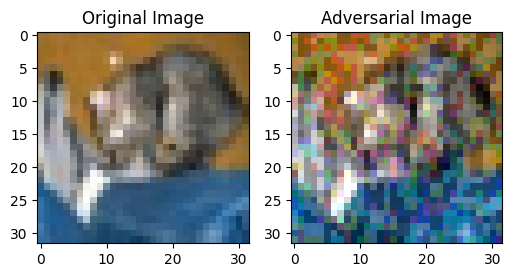

Epsilon=0.10: original pred=cat, adv pred=dog

=== FGSM accuracy vs epsilon ===
Epsilon   Correct   Total     Robust Acc (%) 
0.00      1000      1000      100.00         
0.01      260       1000      26.00          
0.05      4         1000      0.40           
0.10      2         1000      0.20           
0.20      3         1000      0.30           
0.30      5         1000      0.50           


In [3]:
# FGSM 攻击函数
def fgsm_attack(model, x, y, epsilon):
    """
    使用 FGSM 生成对抗样本。
    x 为真实样本，y 为真实标签。
    """
    x = x.clone().detach().requires_grad_(True)
    output = model(x)
    loss = F.cross_entropy(output, y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1)

# 可视化一个 FGSM 示例
epsilon_demo = 0.1
x_adv_fgsm = fgsm_attack(model, x, y, epsilon_demo)
show_images(x, x_adv_fgsm)
orig_pred = model(x).argmax(dim=1).item()
adv_pred = model(x_adv_fgsm).argmax(dim=1).item()
print(f"Epsilon={epsilon_demo:.2f}: original pred={classes[orig_pred]}, adv pred={classes[adv_pred]}")

# 测试多个 epsilon 值，输出准确率 vs epsilon 表格
epsilons = [0, 0.01, 0.05, 0.1, 0.2, 0.3]
print("\n=== FGSM accuracy vs epsilon ===")
print(f"{'Epsilon':<10}{'Correct':<10}{'Total':<10}{'Robust Acc (%)':<15}")
for eps in epsilons:
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        # 仅使用模型原本分类正确的样本
        if model(images).argmax(dim=1).item() != labels.item():
            continue
        adv = fgsm_attack(model, images, labels, eps)
        adv_pred = model(adv).argmax(dim=1)
        correct += (adv_pred == labels).sum().item()
        total += 1
        if total >= 1000:
            break
    acc = 100.0 * correct / total if total > 0 else 0.0
    print(f"{eps:<10.2f}{correct:<10}{total:<10}{acc:<15.2f}")


In [4]:
# PGD 攻击函数
def pgd_attack(model, x, y, epsilon, alpha, num_iter):
    """
    PGD 迭代攻击（untargeted）。
    """
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0, 1).requires_grad_(True)
    for _ in range(num_iter):
        output = model(x_adv)
        loss = F.cross_entropy(output, y)
        model.zero_grad()
        loss.backward()
        x_adv = x_adv.detach() + alpha * x_adv.grad.sign()
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1).requires_grad_(True)
    return x_adv

# CIFAR-10 常用 PGD 参数：epsilon=8/255, alpha=2/255, num_iter=20
eps_pgd = 8 / 255
alpha_pgd = 2 / 255
num_iter_pgd = 20

success = 0
total = 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    if model(images).argmax(dim=1).item() != labels.item():
        continue
    adv = pgd_attack(model, images, labels, eps_pgd, alpha_pgd, num_iter_pgd)
    if model(adv).argmax(dim=1).item() != labels.item():
        success += 1
    total += 1
    if total >= 100:
        break

print(f"PGD Attack: epsilon={eps_pgd:.4f}, alpha={alpha_pgd:.4f}, iterations={num_iter_pgd}")
print(f"Attack Success Rate (ASR) over {total} correctly-classified samples: {100.0*success/total:.2f}%")


PGD Attack: epsilon=0.0314, alpha=0.0078, iterations=20
Attack Success Rate (ASR) over 100 correctly-classified samples: 100.00%


下面这张折线图展示了 FGSM 攻击在不同 epsilon（扰动强度）下模型准确率的变化。epsilon 越大，对抗扰动越强，模型在对抗样本上的准确率通常越低。水平虚线表示模型在干净样本上的基线准确率，便于对比。

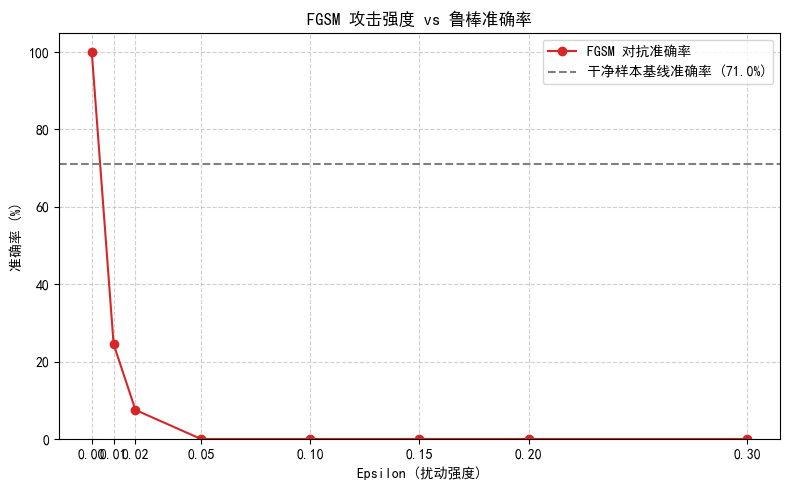

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# 设置中文字体（如系统存在 SimHei）
try:
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

# 用于绘图的 epsilon 列表
epsilons = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
max_samples = 200

# 计算基线准确率（干净样本）
model.eval()
baseline_correct = 0
baseline_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        baseline_correct += (preds == labels).sum().item()
        baseline_total += labels.size(0)
        if baseline_total >= max_samples:
            break
baseline_acc = 100.0 * baseline_correct / baseline_total

# 计算不同 epsilon 下的 FGSM 对抗准确率
fgsm_accs = []
for eps in epsilons:
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        # 只选用模型原本预测正确的样本
        if model(images).argmax(dim=1).item() != labels.item():
            continue
        adv = fgsm_attack(model, images, labels, eps)
        with torch.no_grad():
            adv_pred = model(adv).argmax(dim=1)
        correct += (adv_pred == labels).sum().item()
        total += 1
        if total >= max_samples:
            break
    acc = 100.0 * correct / total if total > 0 else 0.0
    fgsm_accs.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, marker='o', linestyle='-', color='tab:red', label='FGSM 对抗准确率')
plt.axhline(baseline_acc, color='gray', linestyle='--', label=f'干净样本基线准确率 ({baseline_acc:.1f}%)')
plt.title('FGSM 攻击强度 vs 鲁棒准确率')
plt.xlabel('Epsilon (扰动强度)')
plt.ylabel('准确率 (%)')
plt.xticks(epsilons)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


下面这张分组柱状图对比了 FGSM 与 PGD 在相同 epsilon 下的攻击成功率（ASR）。PGD 是多步迭代攻击，通常比单步 FGSM 更强，因此柱状图能直观体现两者差异。

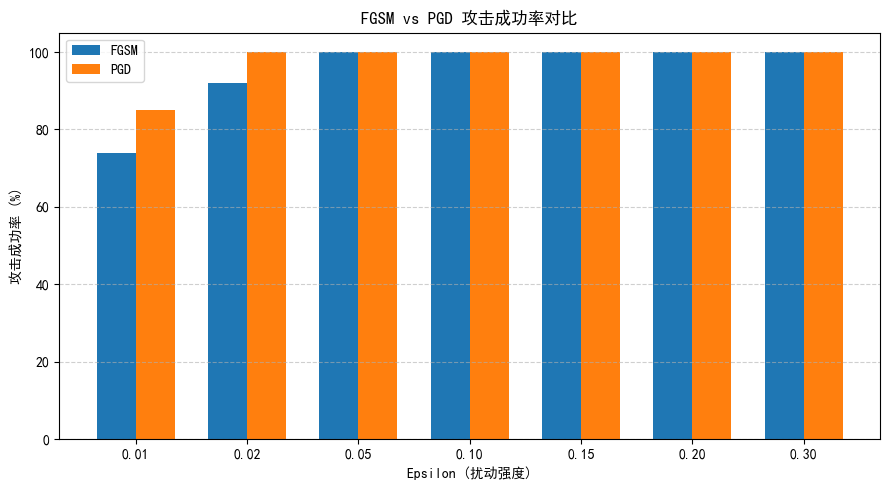

In [6]:
# 选择用于对比的 epsilon 值
eps_compare = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
max_samples = 100  # 为节省计算时间，PGD 使用 100 个样本
num_iter = 20
alpha = 0.005

# 先收集一组模型原本分类正确的样本，确保 FGSM 与 PGD 在相同样本上比较
samples = []
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        if model(images).argmax(dim=1).item() == labels.item():
            samples.append((images, labels))
    if len(samples) >= max_samples:
        break

fgsm_asr = []
pgd_asr = []
for eps in eps_compare:
    # FGSM
    success = 0
    for images, labels in samples:
        adv = fgsm_attack(model, images, labels, eps)
        with torch.no_grad():
            if model(adv).argmax(dim=1).item() != labels.item():
                success += 1
    fgsm_asr.append(100.0 * success / len(samples))

    # PGD
    success = 0
    for images, labels in samples:
        adv = pgd_attack(model, images, labels, eps, alpha, num_iter)
        with torch.no_grad():
            if model(adv).argmax(dim=1).item() != labels.item():
                success += 1
    pgd_asr.append(100.0 * success / len(samples))

x = np.arange(len(eps_compare))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, fgsm_asr, width, label='FGSM', color='tab:blue')
plt.bar(x + width/2, pgd_asr, width, label='PGD', color='tab:orange')
plt.xticks(x, [f'{e:.2f}' for e in eps_compare])
plt.xlabel('Epsilon (扰动强度)')
plt.ylabel('攻击成功率 (%)')
plt.title('FGSM vs PGD 攻击成功率对比')
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 实验结论

- FGSM 是一种单步梯度攻击，增大 `epsilon` 会使对抗扰动更强，模型在对抗样本上的准确率随之下降。
- PGD 是多步迭代攻击，在相同 `epsilon` 下通常比 FGSM 更强；本实验使用 CIFAR-10 上常用的参数 `epsilon=8/255`、`alpha=2/255`、`iterations=20`。
- 在训练好的 SimpleCNN 上使用真实 CIFAR-10 测试图像进行攻击，得到的准确率/成功率才具有实际意义。
